In [1]:
# System
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("../..")

In [2]:
# Setup
from importlib import import_module

import numpy as np
from keras import ops

from src.utils import show_learned_cuts, show_learned_importance

In [3]:
# Parameters
# Dataset
dataset_name = "mock1"
n_samples = 200000
seed = 42

# Model
model_builder_name = "LearnableCutFlowParallel"  # *
centers = [-2, 2, 0, 0]
n_epochs = 200
batch_size = 512

# Plotting
bins = np.linspace(-10, 10, 101)
feature_names = ["x1", "x2", "x3", "x4"]
feature_names_latex = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$"]

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset_name}")
load_data = getattr(module, "load_data")
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 4)
y_train.shape=(100000, 1)
x_test.shape=(100000, 4)
y_test.shape=(100000, 1)


In [5]:
# Model
ModelBuilder = getattr(import_module("src.models"), model_builder_name)
model = ModelBuilder(
    x_train.shape, centers, feature_names=feature_names, name="lcf_par"
)
model.normalization.adapt(x_train)

model.compile(optimizer="adam", loss="crossentropy")
model.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3939
Epoch 2/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3659
Epoch 3/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3446
Epoch 4/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3270
Epoch 5/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3142
Epoch 6/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3042
Epoch 7/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2968
Epoch 8/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 0.2904
Epoch 9/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2845
Epoch 10/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2790
Epoch 11/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2745
Epoch 12/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2706
Epoch 13/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2670
Epoch 14/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2638
Epoch 15/200
196/196 ━━━━━━━━━━━━━━━━━━━

In [6]:
# Analysis: metrics
y_pred = model.predict(x_test, batch_size=batch_size)
y_true = y_test

tp = ops.sum((y_true == 1) & (y_pred == 1))
fp = ops.sum((y_true == 0) & (y_pred == 1))
tn = ops.sum((y_true == 0) & (y_pred == 0))
fn = ops.sum((y_true == 1) & (y_pred == 0))

n_preds_true = ops.add(tp, tn)
n_preds_false = ops.add(fp, fn)
n_positives = ops.add(tp, fp)
n_samples = ops.add(n_preds_true, n_preds_false)

accuracy = ops.divide(n_preds_true, n_samples)
precision = ops.divide(tp, n_positives)
significance = ops.divide(tp, ops.sqrt(fp))

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
True positives.......25906
False positives.........36
Accuracy............0.7601
Precision...........0.9986
Significance.....4317.6670


In [7]:
# Analysis: check metrics via learned cuts
mask = ops.ones_like(x_test[:, 0], dtype="bool")
n_features = x_test.shape[1]
selection = model.learned_importance > 1 / n_features * model.importance_min_percent
for i, cut_report in enumerate(model.learned_cuts_report):
    if not selection[i]:
        continue

    x_i = x_test[:, i]
    boundaries = cut_report["boundaries"]
    index = cut_report["index"]

    if cut_report["case"] == "left":
        mask_i = x_i < boundaries[index]
    elif cut_report["case"] == "right":
        mask_i = x_i > boundaries[index]
    elif cut_report["case"] == "middle":
        mask_i = ops.logical_and(boundaries[0] < x_i, x_i < boundaries[1])
    else:
        mask_i = ops.logical_or(x_i < boundaries[0], boundaries[1] < x_i)
    mask = ops.logical_and(mask, mask_i)

y_pred_cut = ops.cast(mask, dtype="float32")
y_pred_cut = ops.reshape(y_pred_cut, y_test.shape)
tp = ops.sum((y_pred_cut == 1) & (y_test == 1))
fp = ops.sum((y_pred_cut == 1) & (y_test == 0))
tn = ops.sum((y_pred_cut == 0) & (y_test == 0))
fn = ops.sum((y_pred_cut == 0) & (y_test == 1))

n_preds_true = ops.add(tp, tn)
n_preds_false = ops.add(fp, fn)
n_positives = ops.add(tp, fp)
n_samples = ops.add(n_preds_true, n_preds_false)

accuracy = ops.divide(n_preds_true, n_samples)
precision = ops.divide(tp, n_positives)
significance = ops.divide(tp, ops.sqrt(fp))

print(f"True positives..{tp:.>10}")
print(f"False positives.{fp:.>10}")
print(f"Accuracy........{accuracy:.>10.4f}")
print(f"Precision.......{precision:.>10.4f}")
print(f"Significance....{significance:.>10.4f}")

True positives.......25906
False positives.........36
Accuracy............0.7601
Precision...........0.9986
Significance.....4317.6670


In [8]:
# Analysis: learned cuts
for learned_cut in model.learned_cuts:
    print(learned_cut)

x1 < 0.0214
x2 > -0.0079
-3.0620 < x3 < 3.0445
x4 < -3.0160 or x4 > 3.0135


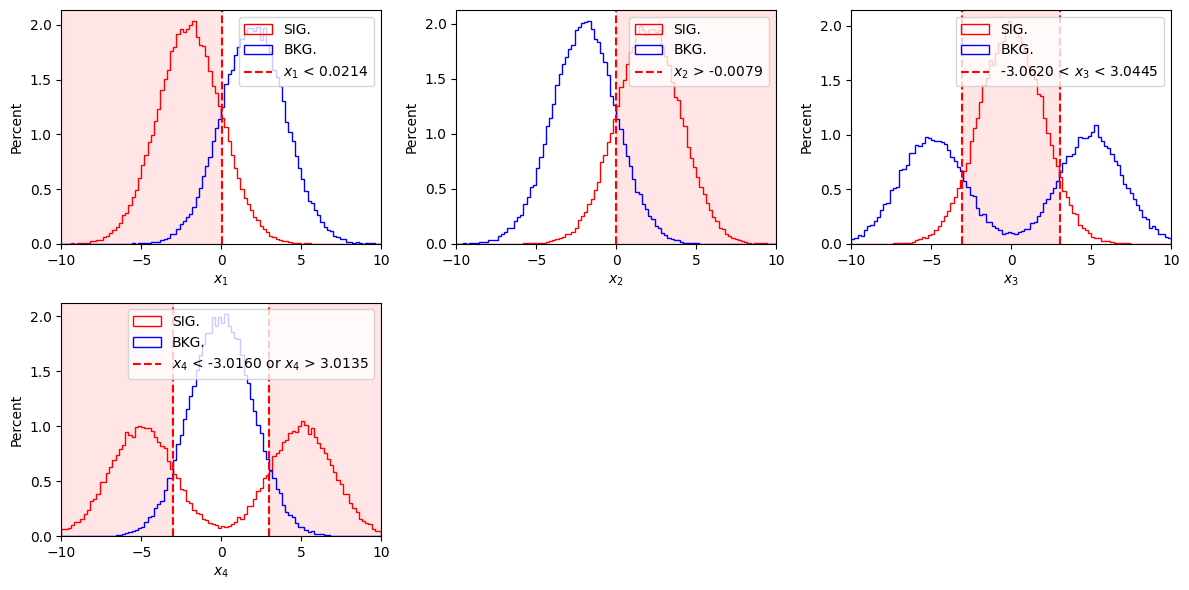

In [9]:
# Figure: learned cuts
show_learned_cuts(model, x_test, y_test, bins, feature_names_latex)

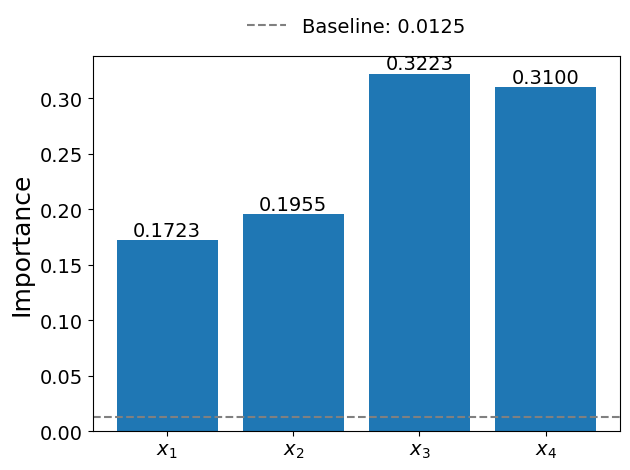

In [10]:
# Figure: learned importance
show_learned_importance(model, feature_names_latex)